# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import savgol_filter


current_state = 'arkansas'

config = {
    'arkansas': {
        'file': '../data/raw/mctnet_preprocessed_arkansas_2021.csv',
        'title': 'Arkansas 2021',
        'mapping': {
            1.0: "Corn",
            2.0: "Cotton",
            3.0: "Rice",
            5.0: "Soybean",
        }
    },
    'california': {
        'file': '../data/raw/mctnet_preprocessed_california_2021.csv',
        'title': 'California 2021',
        'mapping': {
            1.0: "Grapes",
            2.0: "Rice",
            3.0: "Alfalfa",
            4.0: "Almonds",
            5.0: "Pistachios",
            99: "others"
        }
    }
}

selected = config[current_state]

selected = config[current_state]

# Inspection générale du CSV

In [ ]:
df = pd.read_csv(selected['file'])

print(f"--- ANALYSE DE L'ÉTAT : {selected['title']} ---")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")



cols_apercu = ["system:index", "label"] + [c for c in df.columns if "_t01" in c]
print("\nAperçu des données (échantillon t01) :")
display(df[cols_apercu].head())

--- ANALYSE DE L'ÉTAT : Arkansas 2021 ---
Nombre de lignes : 10000
Nombre de colonnes : 364

Aperçu des données (échantillon t01) :


,system:index,label,B11_t01,B12_t01,B2_t01,B3_t01,B4_t01,B5_t01,B6_t01,B7_t01,B8A_t01,B8_t01
0,10810_0,3,0.23475,0.16775,0.0635,0.10030,0.1327,0.15465,0.16525,0.17625,0.18915,0.1885
1,17277_0,3,0.17980,0.11230,0.0418,0.05440,0.0667,0.09410,0.10810,0.12130,0.14060,0.1346
2,12440_0,5,0.22910,0.15760,0.0572,0.08300,0.1114,0.14240,0.14910,0.16450,0.18430,0.1624
3,44910_0,3,0.17950,0.11080,0.0450,0.06660,0.0773,0.11260,0.14600,0.16550,0.17820,0.1880
4,43051_0,5,0.07130,0.04645,0.0257,0.02915,0.0361,0.04055,0.04330,0.04660,0.05340,0.0520


# Analyse des valeurs manquantes

In [ ]:
total_cells = np.prod(df.shape)
total_missing = df.isnull().sum().sum()
missing_rate_global = (total_missing / total_cells) * 100

print(f"--- ANALYSE DES VALEURS MANQUANTES ({selected['title']}) ---")
print(f"Taux global de valeurs manquantes : {missing_rate_global:.2f}%")


missing_by_col = df.isnull().sum()
cols_with_missing = missing_by_col[missing_by_col > 0]

if not cols_with_missing.empty:
    print("\nColonnes avec des valeurs manquantes :")
    print(cols_with_missing)

    plt.figure(figsize=(10, 4))
    sns.heatmap(df[cols_with_missing.index].isnull(), cbar=False, cmap="viridis")
    plt.title(f"Localisation des manques - {selected['title']}")
    plt.show()
else:
    print("Aucune valeur manquante détectée sur les 363 colonnes.")

--- ANALYSE DES VALEURS MANQUANTES (Arkansas 2021) ---
Taux global de valeurs manquantes : 0.00%
Aucune valeur manquante détectée sur les 363 colonnes.


# Statistiques descriptives

In [ ]:
print(f"--- STATISTIQUES DESCRIPTIVES ({selected['title']}) ---")

print("\nTableau des labels (Codes USDA) :")
print(df['label'].describe())



print("\nStatistiques sur la bande Rouge (B4) au pas de temps 18 (mi-saison) :") #printemp
print(df['B4_t18'].describe())

if '.geo' in df.columns:
    print("\nLe dataset contient des données spatiales (.geo).")

--- STATISTIQUES DESCRIPTIVES (Arkansas 2021) ---

Tableau des labels (Codes USDA) :
count    10000.000000
mean         9.468400
std         22.988563
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max         99.000000
Name: label, dtype: float64

Statistiques sur la bande Rouge (B4) au pas de temps 18 (mi-saison) :
count    10000.000000
mean         0.067844
std          0.062822
min          0.000000
25%          0.023800
50%          0.038550
75%          0.096000
max          0.569200
Name: B4_t18, dtype: float64

Le dataset contient des données spatiales (.geo).


# Calcul du NDVI à partir de B8 et B4

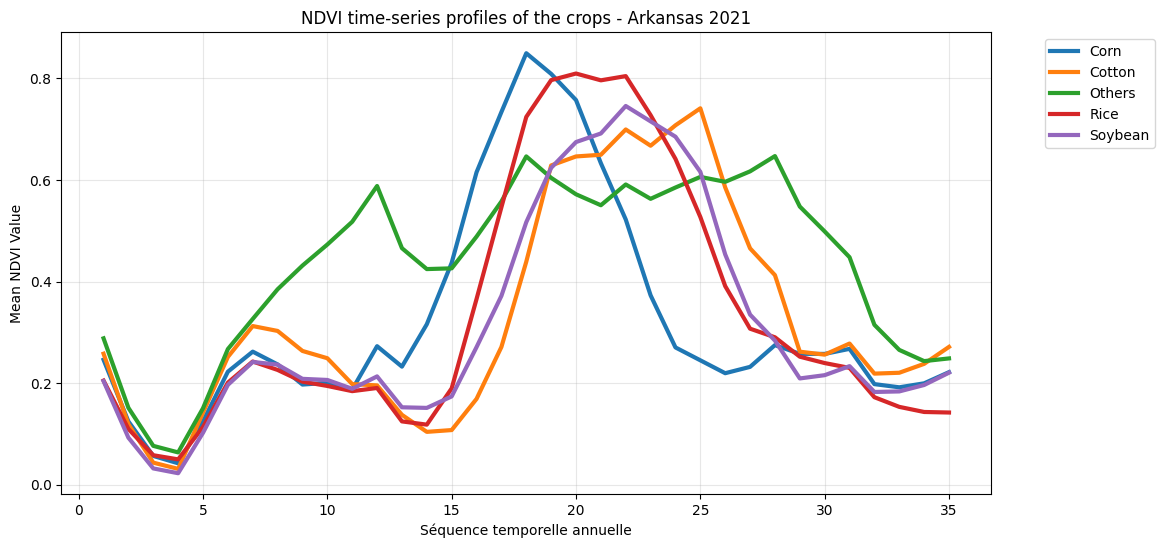

In [ ]:

crop_mapping = selected['mapping']


df_plot = df[df["label"] != 111.0].copy()
df_plot["class_name"] = df_plot["label"].map(crop_mapping).fillna("Others")


ndvi_cols = [f"NDVI_t{t:02d}" for t in range(1, 36)]  # ← 1 à 35
for t in range(1, 36):  # ← 1 à 35
    nir = df_plot[f"B8_t{t:02d}"]
    red = df_plot[f"B4_t{t:02d}"]
    df_plot[f"NDVI_t{t:02d}"] = ((nir - red) / (nir + red + 1e-8)).clip(0, 1)

df_grouped = df_plot.groupby("class_name")[ndvi_cols].mean().T
df_grouped.index = range(1, 36)  # ← 1 à 35

df_smoothed = df_grouped.copy()
for col in df_grouped.columns:
    df_smoothed[col] = savgol_filter(df_grouped[col], window_length=7, polyorder=2)

plt.figure(figsize=(12, 6))

sns.lineplot(data=df_smoothed, dashes=False, linewidth=3)



plt.title(f"NDVI time-series profiles of the crops - {selected['title']}")
plt.xlabel("Séquence temporelle annuelle")
plt.ylabel("Mean NDVI Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Exploration par classes

--- DISTRIBUTION DES CLASSES (Arkansas 2021) ---

Fréquences brutes (Top 10) :
label_name
Soybean    4677
Rice       2423
Corn       1522
Cotton      762
NaN         616
Name: count, dtype: int64


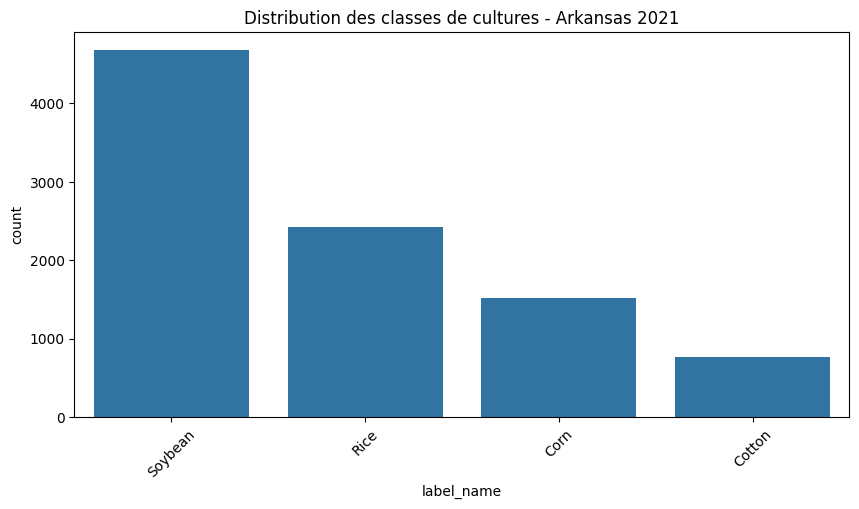

C:\Users\Azur Computer\AppData\Local\Temp\ipykernel_13756\2215658065.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["label_clean"] = df["label"].map(selected['mapping']).fillna("Others")
C:\Users\Azur Computer\AppData\Local\Temp\ipykernel_13756\2215658065.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_final.index, y=counts_final.values, palette="viridis")



Distribution finale (Cultures cibles vs Others) :
label_clean
Soybean    4677
Rice       2423
Corn       1522
Cotton      762
Others      616
Name: count, dtype: int64


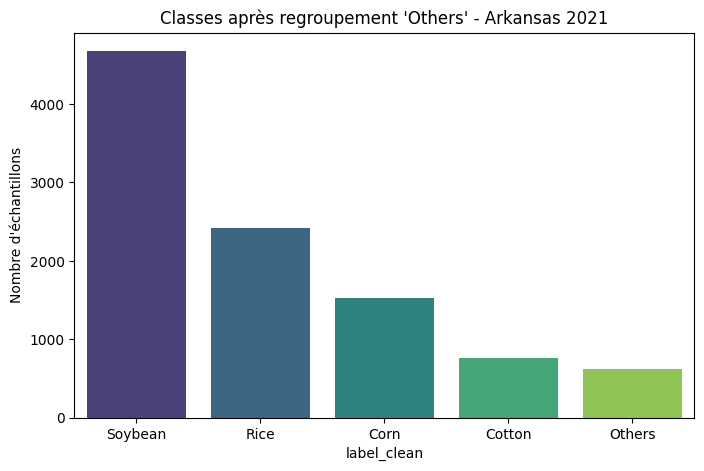

In [ ]:

df["label_name"] = df["label"].map(selected['mapping'])

print(f"--- DISTRIBUTION DES CLASSES ({selected['title']}) ---")
print("\nFréquences brutes (Top 10) :")
print(df["label_name"].value_counts(dropna=False).head(10))

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="label_name", order=df["label_name"].value_counts().index)
plt.title(f"Distribution des classes de cultures - {selected['title']}")
plt.xticks(rotation=45)
plt.show()


df["label_clean"] = df["label"].map(selected['mapping']).fillna("Others")

print("\nDistribution finale (Cultures cibles vs Others) :")
counts_final = df["label_clean"].value_counts()
print(counts_final)

plt.figure(figsize=(8, 5))
sns.barplot(x=counts_final.index, y=counts_final.values, palette="viridis")
plt.title(f"Classes après regroupement 'Others' - {selected['title']}")
plt.ylabel("Nombre d'échantillons")
plt.show()